# Quick Raw-Data Check (IRIS Instruments Syscal Pro)

Run this notebook in the field on newly measured data to get a quick overview of the data quality.

This can be especially useful if you conduct a very fast normal-reciprocal measurement preceeding the actual measurement.

## Settings

FILL out these settings depending on the measurement setup and file names

In [1]:
normal_file = None
reciprocal_file = None
electrode_spacing = None
# change to 72 if the new Syscal Pro is used
nr_electrodes = 48

In [2]:
normal_file = '20181130_01_profil1_normal.bin'
reciprocal_file = '20181130_03_profil2_reziprok.bin'
electrode_spacing = 0.25

In [3]:
# just make sure that user settings were properly set
assert normal_file is not None, "You MUST provide a normal measurement file"
assert electrode_spacing is not None, "You MUST provide a best-guess spacing of electrodes"

In [4]:
import reda
# this is the primary raw-data analysis object that we use
tdip = reda.TDIP()
# import the data
tdip.import_syscal_bin(normal_file)
# we must provide the number of electrodes so we can compute reciprocal configurations
tdip.import_syscal_bin(reciprocal_file, reciprocals=nr_electrodes)

2024-05-17 08:10:37,264 - reda.containers.TDIP           - %INFO       - IRIS Syscal Pro bin import
2024-05-17 08:10:38,795 - reda.containers.TDIP           - %INFO       - Data sized changed from 0 to 1460
2024-05-17 08:10:38,795 - reda.containers.TDIP           - %INFO       - IRIS Syscal Pro bin import
2024-05-17 08:10:40,248 - reda.containers.TDIP           - %INFO       - Data sized changed from 1460 to 2920


In [5]:
# convert the time-domain ip container into a complex-resistivity container
cr = tdip.to_cr()

# compute geometric factors based on the best-guess electrode spacing
# note: This is only useful for a quick analysis of data in the field.
#       Especially if significant topography is encountered, we need
#       detailed electrode positions.
_ = cr.compute_K_analytical(spacing=electrode_spacing)

## Tabular analysis

The following cells print out some some minimum/maximum values.

Look for common electrodes, or patterns, in these lists.

* Is one electrode always involved for low currents or high differences?

In [6]:
# print the ten lowest currents
cr.data.sort_values('Iab')[['a', 'b', 'm', 'n', 'id', 'Iab']].iloc[0:10]

,a,b,m,n,id,Iab
2917,45,46,48,47,2134,0.143411
2918,45,46,48,47,2134,0.145209
2,3,4,2,1,91,0.157042
3,4,3,1,2,91,0.159126
25,5,7,3,1,192,0.175746
44,6,8,4,2,232,0.202584
2879,42,44,48,46,2124,0.219148
2799,41,43,47,45,2094,0.227995
6,4,5,2,1,123,0.298767
11,4,5,3,2,125,0.298767


In [7]:
cr.data.sort_values('rdiff')[['a', 'b', 'm', 'n', 'id', 'rdiff', 'rho_a']].iloc[-10:]

,a,b,m,n,id,rdiff,rho_a
2676,42,43,45,44,2043,166.458952,684.981905
2679,44,45,43,42,2043,166.458952,783.281645
2756,45,46,44,43,2074,178.692236,841.370628
2757,43,44,46,45,2074,178.692236,516.085077
2758,43,44,46,45,2074,178.692236,516.974925
2759,45,46,44,43,2074,178.692236,841.874169
2837,46,47,45,44,2104,182.836349,862.177576
2838,44,45,47,46,2104,182.836349,563.066095
2839,44,45,47,46,2104,182.836349,562.738221
2836,46,47,45,44,2104,182.836349,861.342287


In [8]:
cr.data.sort_values('rphadiff')[['a', 'b', 'm', 'n', 'id', 'rphadiff', 'rpha']].iloc[-10:]

,a,b,m,n,id,rphadiff,rpha
904,22,23,16,15,987,36.254824,-4.062106
905,15,16,23,22,987,36.254824,32.147470
902,22,23,16,15,987,36.254824,-3.791312
903,15,16,23,22,987,36.254824,32.508759
2362,40,42,20,18,1915,55.802631,-3.052841
2363,18,20,42,40,1915,55.802631,52.749790
970,14,15,24,23,1043,62.893135,61.856958
973,23,24,15,14,1043,62.893135,-0.585469
972,23,24,15,14,1043,62.893135,-0.626141
971,14,15,24,23,1043,62.893135,62.717703


## Histogram Analysis

### Currents

* Any zero-injections? Possible causes:
  * Bad electrode contact
  * Lost connection between electrode and cable

### Resistances

* We would expect mainly positive resistances (except for measurements on high-contrast regions)
* We are looking for large outliers

### Resistance-Differences

* We expect more or less normally-distributed log10 values

### Phase values

* Usually we expect most phase values to lie somewhere between -50 mrad and 0 mrad
  * beware of the negative IP effect -> expect a few phase values up to 20 mrad
* Look for outliers


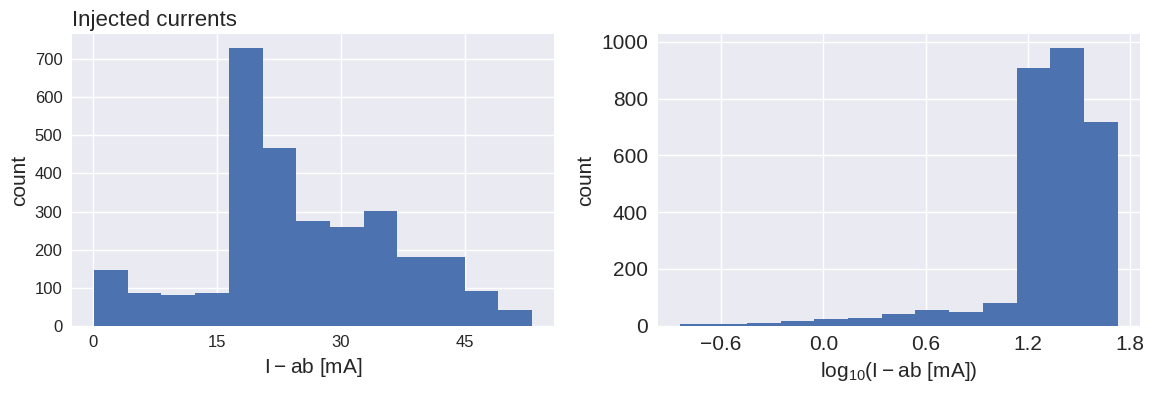

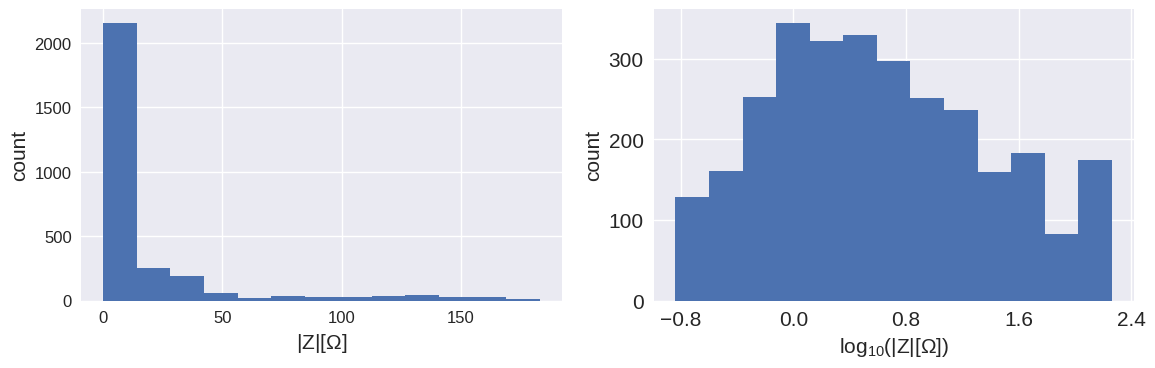

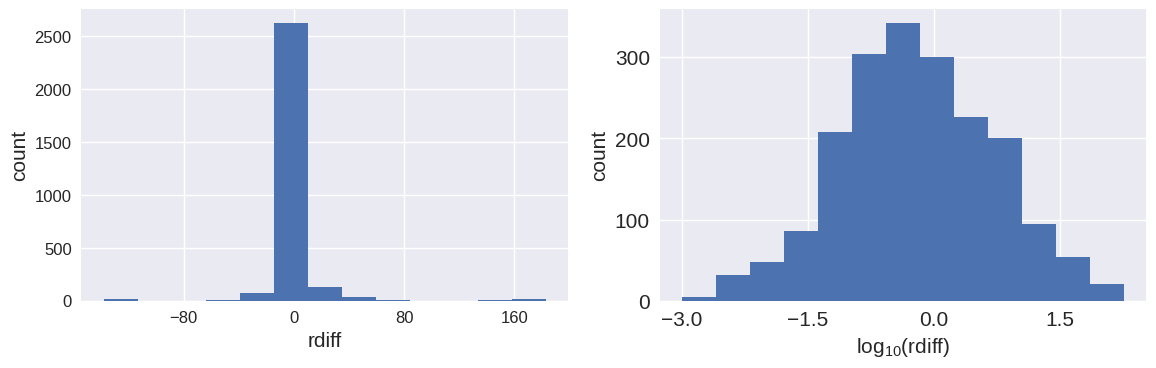

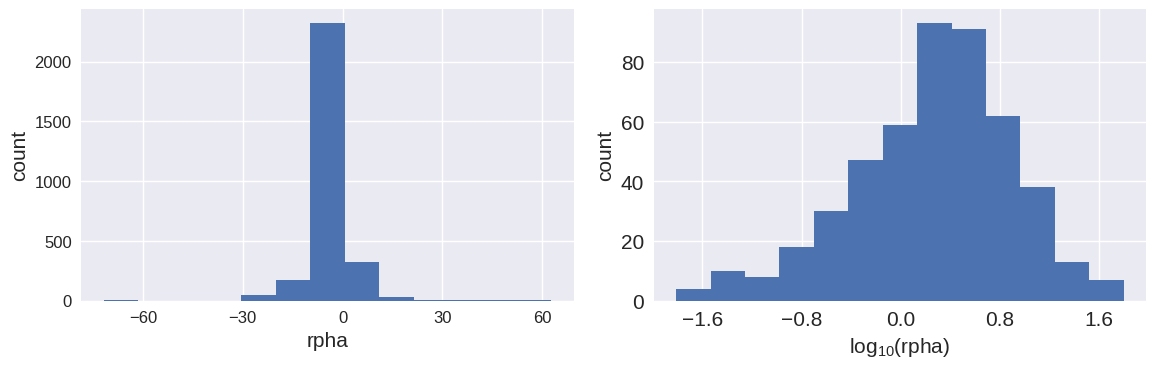

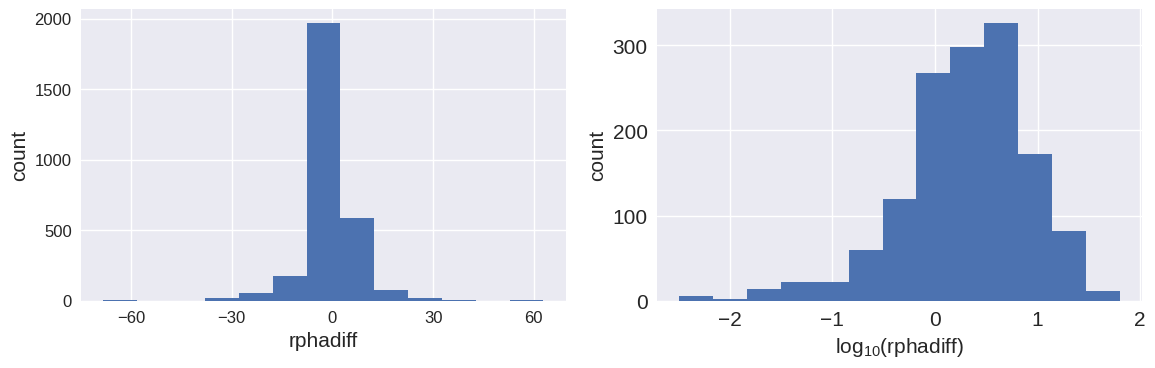

In [9]:
_ = cr.plot_histogram('Iab', log10=True, title='Injected currents')
_ = cr.plot_histogram('r', log10=True)
_ = cr.plot_histogram('rdiff', log10=False)
_ = cr.plot_histogram('rpha', log10=False)
_ = cr.plot_histogram('rphadiff', log10=False)

## Pseudosections

We use two different types of pseudosections here. The first one should be usable for most configurations, while the second one is best used only with Dipole-Dipole data!

They provide a visual overview of normal reciprocal behavior

* We expect the symmetry to brake down towards the deeper configurations (upper left and lower right corners

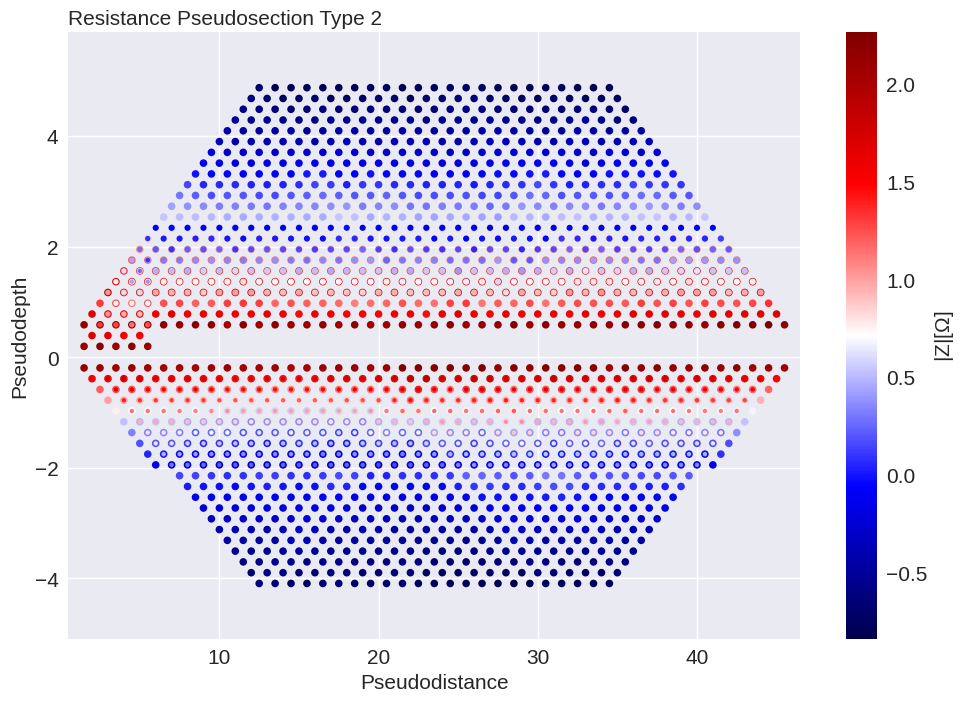

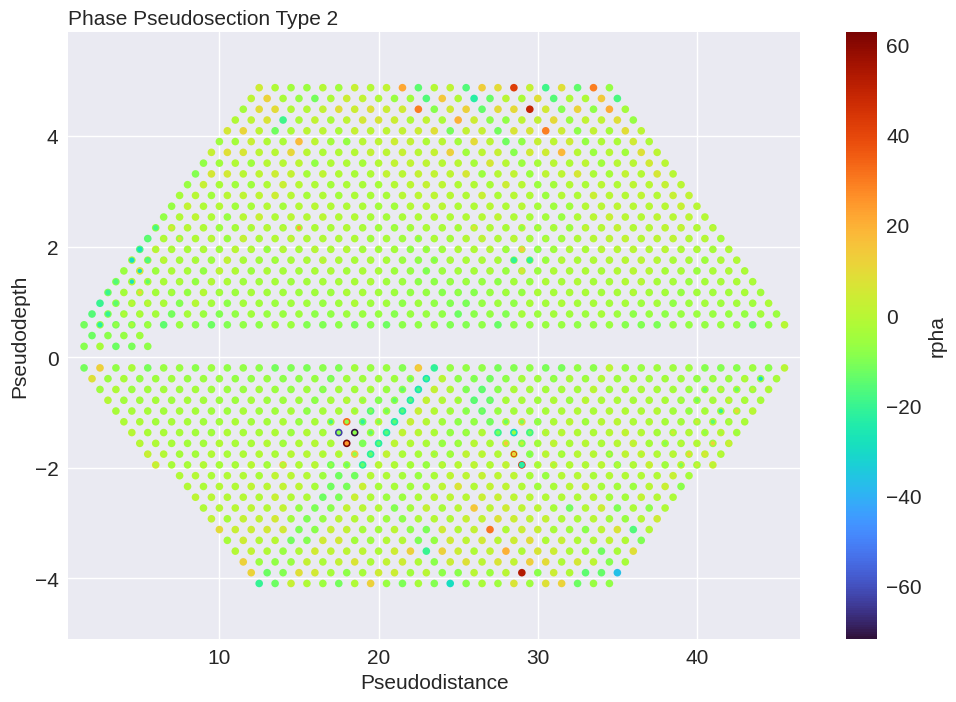

In [10]:
_ = cr.pseudosection_type2(
    column='r',
    log10=True,
    markersize=30,
    title='Resistance Pseudosection Type 2',
    # sometimes you want a little bit more contrast in your colormap, even at the expense of
    # introducing optical bias
    # try the colormaps: viridis (default), turbo, jet, seismic
    cmap='seismic',
)
_ = cr.pseudosection_type2(
    column='rpha',
    log10=False,
    markersize=30,
    title='Phase Pseudosection Type 2',
    # sometimes you want a little bit more contrast in your colormap, even at the expense of
    # introducing optical bias
    # try the colormaps: viridis (default), turbo, jet, seismic
    cmap='turbo',
)

found duplicate coordinates!
found duplicate coordinates!


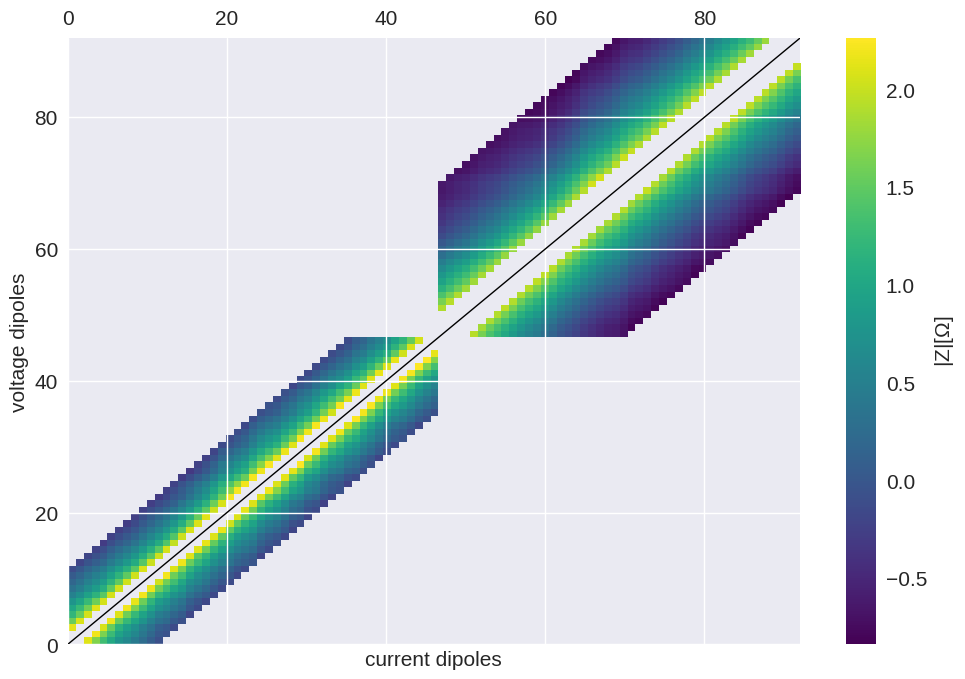

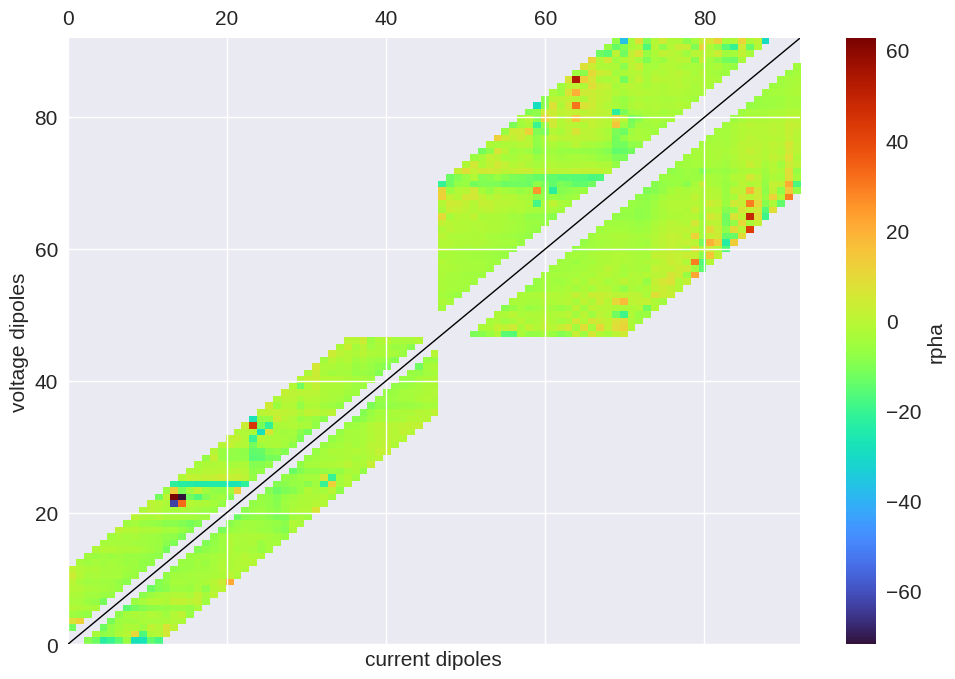

In [11]:
_ = cr.pseudosection(column='r', log10=True)
_ = cr.pseudosection(column='rpha', log10=False, cmap='turbo')

## Error Model for R
Bin analysis based on normal-reciprocal differences

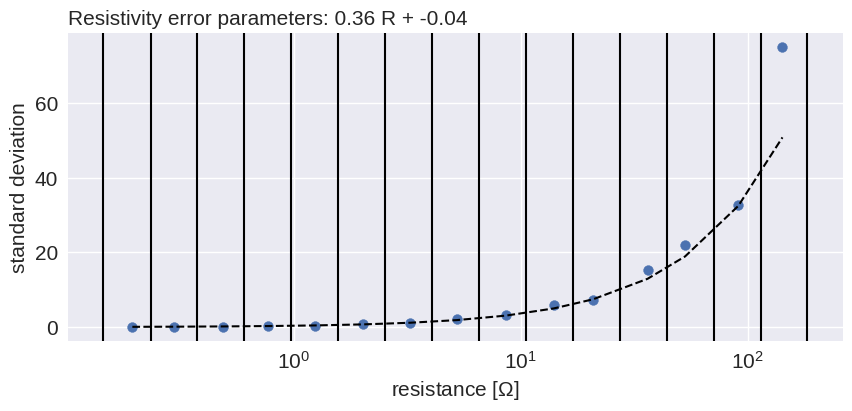

In [12]:
from reda.utils.norrec import compute_error_model_absolute_relative
_ = compute_error_model_absolute_relative(cr.data, nbin=15)